# 05 — Cross-dataset generalization

The central question (Planejamento §10): do the models learn **general phishing
patterns**, or just **memorize one dataset**? We train on one raw-URL dataset and
test on a *different* one (**Mendeley** and the Kaggle **malicious_urls** set), in
both directions, for RF / XGBoost / CNN-LSTM.

```bash
python -m src.experiments.run_cross --all
```

Each run records a **within** baseline (train A → A's held-out test) and the
**cross** result (train A → all of B), both on the same trained model.

In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd()
REPO_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import METRICS_CROSSDATASET_CSV
from src.data.loaders import load_raw
sns.set_theme(style="whitegrid")
print("setup ok")

setup ok


## 1. The URL-formatting artifact (why normalization matters)

Before trusting any cross-dataset number, note that the two datasets format URLs
very differently. Lexical features like `has_https`, `url_length`, and `path_depth`
depend on whether the scheme (`http(s)://`) is present — so without normalization,
cross-dataset transfer measures *formatting*, not phishing. We strip the scheme
(D-010) before extracting features / tokenizing.

In [2]:
men = load_raw("mendeley")["url"].astype(str)
mal = load_raw("malicious_urls")["url"].astype(str)
print(f"Mendeley URLs with a scheme (://):  {100*men.str.contains('://').mean():.1f}%")
print(f"Malicious URLs with a scheme (://): {100*mal.str.contains('://').mean():.1f}%")
print("\n=> normalization (scheme stripping) is applied in the cross-dataset runner.")

Mendeley URLs with a scheme (://):  100.0%
Malicious URLs with a scheme (://): 11.5%

=> normalization (scheme stripping) is applied in the cross-dataset runner.


## 2. Results — within vs. cross (normalized)

In [3]:
df = pd.read_csv(METRICS_CROSSDATASET_CSV)
df["kind"] = df.apply(lambda r: "within" if r.train_dataset == r.test_dataset else "cross", axis=1)
df.sort_values(["train_dataset", "model", "kind"]).reset_index(drop=True)

,model,train_dataset,test_dataset,accuracy,precision,recall,f1,auc_roc,train_time_s,inference_time_ms_per_sample,kind
0,CNN-LSTM,malicious_urls,mendeley,0.4853,0.3999,0.7442,0.5202,0.4534,148.0261,0.029604,cross
1,CNN-LSTM,malicious_urls,malicious_urls,0.9061,0.6767,0.9170,0.7787,0.9714,148.0261,0.030256,within
2,RandomForest,malicious_urls,mendeley,0.5798,0.4322,0.3841,0.4067,0.5901,1572.0934,0.140164,cross
3,RandomForest,malicious_urls,malicious_urls,0.9065,0.7127,0.8056,0.7563,0.9497,1572.0934,0.046123,within
4,XGBoost,malicious_urls,mendeley,0.6017,0.4591,0.3486,0.3963,0.6155,198.5635,0.005478,cross
5,XGBoost,malicious_urls,malicious_urls,0.9105,0.7421,0.7713,0.7564,0.9459,198.5635,0.006833,within
6,CNN-LSTM,mendeley,malicious_urls,0.7299,0.3156,0.4266,0.3628,0.6423,83.5824,0.026096,cross
7,CNN-LSTM,mendeley,mendeley,0.9537,0.9392,0.9371,0.9382,0.9905,83.5824,0.031307,within
8,RandomForest,mendeley,malicious_urls,0.6109,0.2226,0.4650,0.3011,0.6032,692.6162,0.056287,cross
9,RandomForest,mendeley,mendeley,0.8801,0.8411,0.8387,0.8399,0.9501,692.6162,0.045273,within


## 3. The generalization drop

For each model and training dataset: within-dataset F1 vs. the cross-dataset F1, and the gap. A large drop ⇒ the model memorized the training dataset.

In [4]:
rows = []
for (model, train), g in df.groupby(["model", "train_dataset"]):
    w = g[g.test_dataset == train]
    c = g[g.test_dataset != train]
    if len(w) and len(c):
        rows.append({
            "model": model, "trained_on": train, "tested_on (cross)": c["test_dataset"].iloc[0],
            "within_f1": w["f1"].iloc[0], "cross_f1": c["f1"].iloc[0],
            "within_auc": w["auc_roc"].iloc[0], "cross_auc": c["auc_roc"].iloc[0],
            "f1_drop": round(w["f1"].iloc[0] - c["f1"].iloc[0], 3),
        })
comp = pd.DataFrame(rows).sort_values("f1_drop", ascending=False).reset_index(drop=True)
comp

,model,trained_on,tested_on (cross),within_f1,cross_f1,within_auc,cross_auc,f1_drop
0,CNN-LSTM,mendeley,malicious_urls,0.9382,0.3628,0.9905,0.6423,0.575
1,RandomForest,mendeley,malicious_urls,0.8399,0.3011,0.9501,0.6032,0.539
2,XGBoost,mendeley,malicious_urls,0.8454,0.3168,0.9531,0.6234,0.529
3,XGBoost,malicious_urls,mendeley,0.7564,0.3963,0.9459,0.6155,0.360
4,RandomForest,malicious_urls,mendeley,0.7563,0.4067,0.9497,0.5901,0.350
5,CNN-LSTM,malicious_urls,mendeley,0.7787,0.5202,0.9714,0.4534,0.258


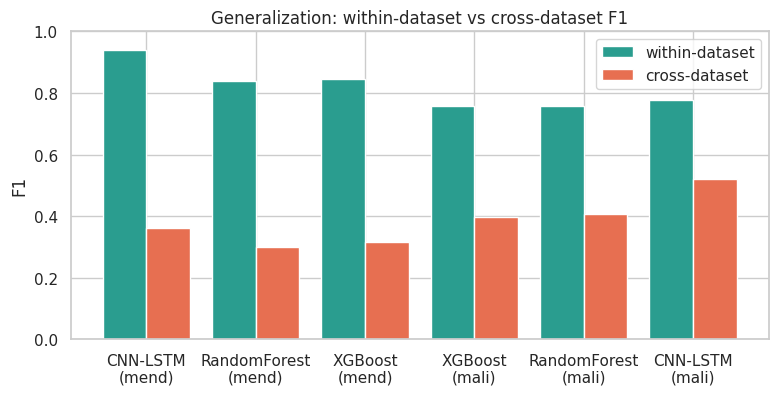

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = comp["model"] + "\n(" + comp["trained_on"].str[:4] + ")"
x = range(len(comp))
ax.bar([i - 0.2 for i in x], comp["within_f1"], width=0.4, label="within-dataset", color="#2a9d8f")
ax.bar([i + 0.2 for i in x], comp["cross_f1"], width=0.4, label="cross-dataset", color="#e76f51")
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel("F1"); ax.set_ylim(0, 1)
ax.set_title("Generalization: within-dataset vs cross-dataset F1")
ax.legend()
plt.show()

## 4. Interpretation

- A **small** drop means the model learned transferable phishing patterns.
- A **large** drop means it overfit to dataset-specific quirks — itself a valid and
  important finding (Planejamento §10). It also highlights how dataset construction
  (URL formatting, collection method, label balance) shapes "phishing detection"
  benchmarks.
- Compare the **char-level CNN-LSTM** to the **lexical** classical models: whichever
  drops less generalizes better.

## 5. Exit criterion

`metrics_crossdataset.csv` populated (within + cross, both directions); each run has
a confusion matrix + ROC; the F1 drop is the headline. Next: Phase 7 (final figures).